## Initialize

In [1]:
import pandas as pd
import ollama
from experiments.crowd import WeatherDemo
import json
# from experiments import utils
# from experiments.experiments import MorseExperiment, LeetExperiment, GematriaExperiment, SpellingExperiment, CypherExperiment, JeopardyExperiment

print(ollama.list())

{'models': [{'name': 'qwen2.5:latest', 'model': 'qwen2.5:latest', 'modified_at': '2025-04-02T16:06:38.932341123-04:00', 'size': 4683087332, 'digest': '845dbda0ea48ed749caafd9e6037047aa19acfcfd82e704d7ca97d631a0b697e', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'qwen2', 'families': ['qwen2'], 'parameter_size': '7.6B', 'quantization_level': 'Q4_K_M'}}, {'name': 'llama2:latest', 'model': 'llama2:latest', 'modified_at': '2025-04-02T15:51:47.546633006-04:00', 'size': 3826793677, 'digest': '78e26419b4469263f75331927a00a0284ef6544c1975b826b15abdaef17bb962', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'llama', 'families': ['llama'], 'parameter_size': '7B', 'quantization_level': 'Q4_0'}}, {'name': 'mistral:latest', 'model': 'mistral:latest', 'modified_at': '2025-03-10T18:39:58.398861042-04:00', 'size': 4113301824, 'digest': 'f974a74358d62a017b37c6f424fcdf2744ca02926c4f952513ddf474b2fa5091', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'llama', 'fa

## Generationg Content List for Role-Playing

In [3]:
import json

df_zeroshot = pd.read_csv("logs/weather_mistral_experiment_log_20250702_153332.csv", encoding="utf-8-sig").iloc[:-1]
df_fewshot = pd.read_csv("logs/weather_mistral_experiment_log_20250702_142117.csv",encoding="utf-8-sig").iloc[:-1]

df_fewshot["Prompting"] = "fewshot"
df_zeroshot["Prompting"] = "zeroshot"
df_all = pd.concat([df_fewshot, df_zeroshot]).sort_values(by=["Challenge", "Prompting"])

grouped = df_all.groupby("Challenge")

content_list = []
for challenge, group in grouped:
    if group.shape[0] < 2:
        continue
    prompt = group.iloc[0]["Prompt"]
    answers = list(group.sort_values(by="Prompting")["LLM Result"])
    characters = list(group.sort_values(by="Prompting")["Prompting"])
    content_list.append({
        "questions": [prompt],
        "answers": answers,
        "characters": characters
    })

for item in content_list:
    fixed_characters = []
    for c in item["characters"]:
        if c == "fewshot":
            fixed_characters.append("fewshot-weather man-mistral")
        elif c == "zeroshot":
            fixed_characters.append("zeroshot-weather man-mistral")
        else:
            fixed_characters.append(c)
    item["characters"] = fixed_characters

with open("data/weather/roleplaying_mistral_100fewzeroshot.json", "w", encoding='utf-8') as f:
    json.dump(content_list, f, indent=2, ensure_ascii=False)

In [6]:
with open ('data/weather/roleplaying_mistral_100fewzeroshot.json', 'r') as f:
    data = json.load(f)

for item in data[:1]:
    print(item)

{'questions': ['Given the weather observations below, generate a forecast describing the upcoming weather conditions.At 2011-11-22 00:00, in Tulang Bawang Barat, Lampung, the weather observations were recorded as follows:\nEast – west wind speed at 10 meters above ground: 1.56 m/s, North – south wind speed at 10 meters above ground: -1.03 m/s. Dewpoint Temperature: 23.04 °C. Temperature: 24.31 °C. Pressure Mean Sea Level: 1008.38 hPa. Surface Pressure: 1004.84 hPa. Total Precipitation: 0.0000 meters\nAt 2011-11-22 01:00, in Tulang Bawang Barat, Lampung, the weather observations were recorded as follows:\nEast – west wind speed at 10 meters above ground: 1.86 m/s, North – south wind speed at 10 meters above ground: -1.16 m/s. Dewpoint Temperature: 23.21 °C. Temperature: 25.24 °C. Pressure Mean Sea Level: 1009.43 hPa. Surface Pressure: 1005.90 hPa. Total Precipitation: 0.0000 meters\nAt 2011-11-22 02:00, in Tulang Bawang Barat, Lampung, the weather observations were recorded as follows:\

## Few-shot and Zero-shot Setup  & Benchmarking


In [3]:
import json
with open('data/weather/100_random_test_data.jsonl', "r", encoding="utf-8") as f:
    weather_data = [json.loads(line) for line in f]

In [45]:
#Mistral FewShot Result with 100 rows using
import asyncio
import nest_asyncio
nest_asyncio.apply()

from experiments.experiments import WeatherExperiment
from experiments.utils import get_logging

log_prefix = get_logging(
        name= 'mainFewShot_Mistral100Data',
        log_dir='results_log',
        log_prefix='mainFewShot_Mistral100Data',
        rank=0,
        master_only=True
    )

experiment = WeatherExperiment(
        data_list=weather_data[:5],
        log_prefix=log_prefix,
        prompting_mode='fewshot',
        model='mistral',
        concurrency=10
    )

result = experiment.run(logging=True)

In [ ]:
#Mistral ZeroShot Result with 100 rows using

from experiments.experiments import WeatherExperiment
from experiments.utils import get_logging

log_prefix = get_logging(
        name= 'mainZeroShot_Mistral100Data',
        log_dir='results_log',
        log_prefix='mainZeroShot_Mistral100Data',
        rank=0,
        master_only=True
    )

experimentZero = WeatherExperiment(
        data_list=weather_data,
        log_prefix=log_prefix,
        prompting_mode='zeroshot',
        model='mistral',
        concurrency=10
    ).run(logging=True)

## BENCHMARKING MISTRAL, LLAMA, QWEN WITH FEWSHOT AND ZEROSHOT

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import glob
import os
import matplotlib.cm as cm
import numpy as np

In [85]:
file_paths = glob.glob(os.path.join("sample_data_fewshot_pca_Cluster15PCASubCluster/", "*.csv"))
df_list = [pd.read_csv(path) for path in file_paths]
df = pd.concat(df_list, ignore_index=True)

In [12]:
metric1 = [
    'LCS', 'NLCS', 'BertScore', 'CosineSimilarity',
    'BLUE', 'ROUGE-L'
]
metric2 = ['Levenshtein Distance', 'Normalized Levenshtein Distance']

In [77]:
final_rows = []

for file in file_paths:
    df = pd.read_csv(file)

    final_row = df[df.iloc[:, 0] == 'Final Avg.']

    if not final_row.empty:
        data = final_row[metric1 + ['Model', 'Prompting']].copy()
        final_rows.append(data)

In [78]:
print(final_rows[:1])

[     Levenshtein Distance  Normalized Levenshtein Distance    LCS     NLCS  \
100               1172.06                         0.854377  11.49  0.00911   

     BertScore  CosineSimilarity      BLUE   ROUGE-L   Model Prompting  
100   0.075837          0.271585  0.029481  0.264334  llama2  zeroshot  ]


In [83]:
def plot_bar_one_metric_prompting(df, metric, prompt, model_order, color_map):
    prompt_df = df[df['Prompting'] == prompt].copy()

    prompt_df['Model'] = prompt_df['Model'].astype(str)
    prompt_df['Model'] = pd.Categorical(prompt_df['Model'], categories=model_order, ordered=True)
    prompt_df = prompt_df.sort_values('Model')

    values = prompt_df[metric].astype(float).values
    labels = prompt_df['Model'].tolist()
    colors = [color_map[model] for model in labels]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors)
    plt.title(f"{prompt} - {metric}")
    plt.ylabel("Value")
    plt.xlabel("Model")

    y_min = values.min()
    y_max = values.max()
    padding = (y_max - y_min) * 0.1 if y_max != y_min else 1
    plt.ylim(y_min - padding, y_max + padding)

    for i, val in enumerate(values):
        y_pos = val + padding * 0.05 if val >= 0 else val - padding * 0.15
        va_pos = 'bottom' if val >= 0 else 'top'
        plt.text(i, y_pos, f"{val:.4f}", ha='center', va=va_pos)

    plt.tight_layout()
    plt.show()


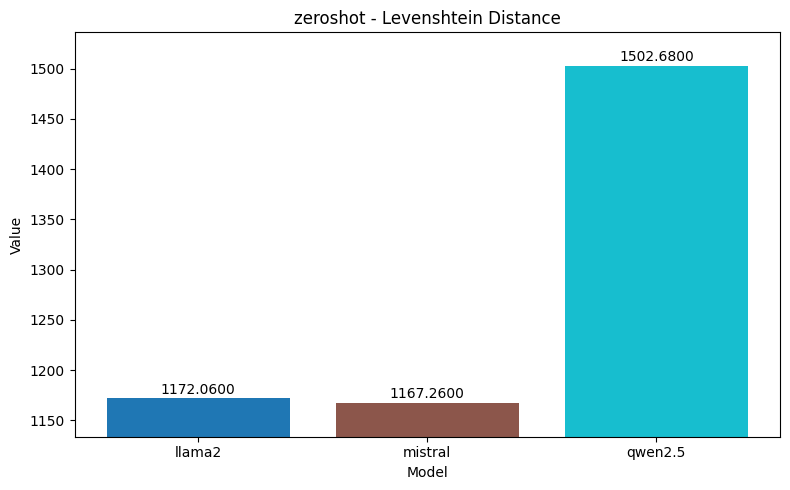

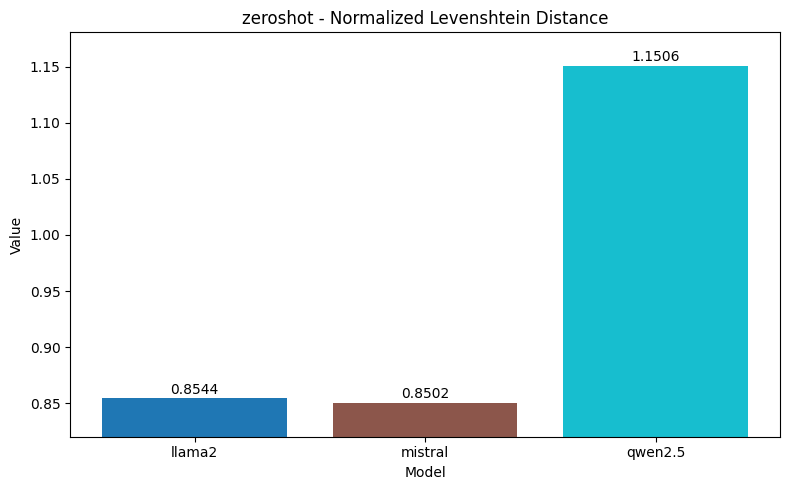

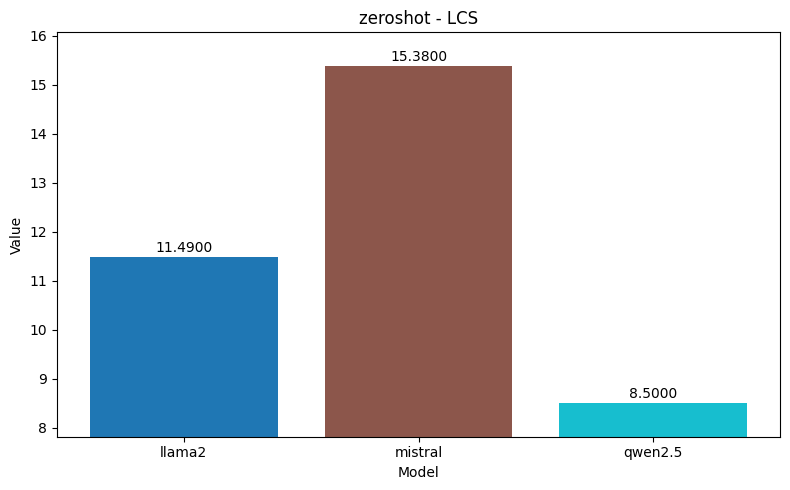

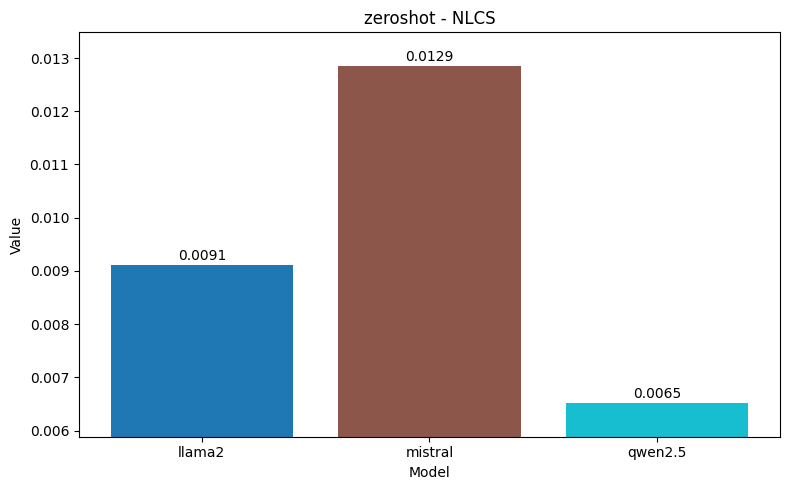

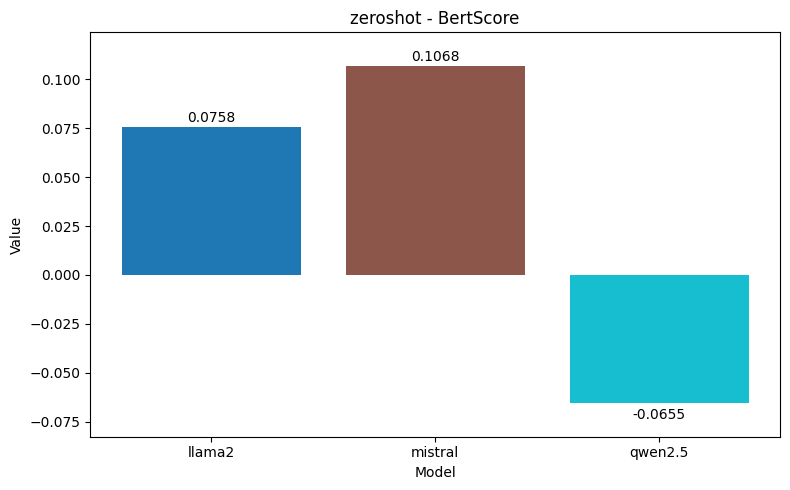

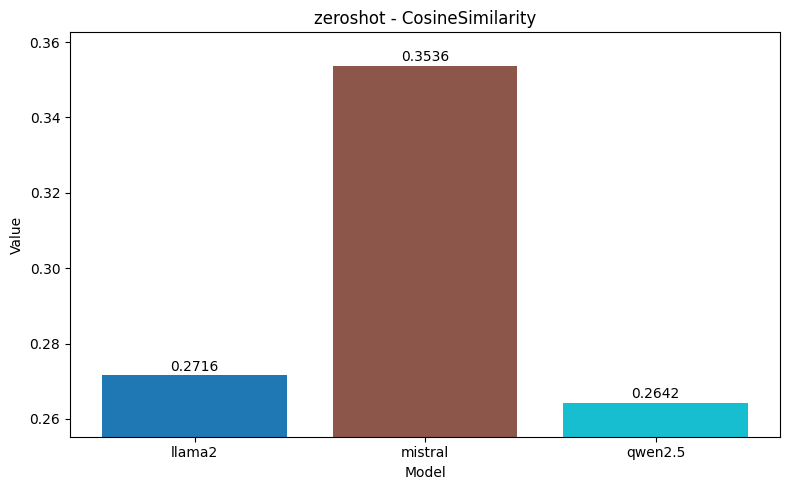

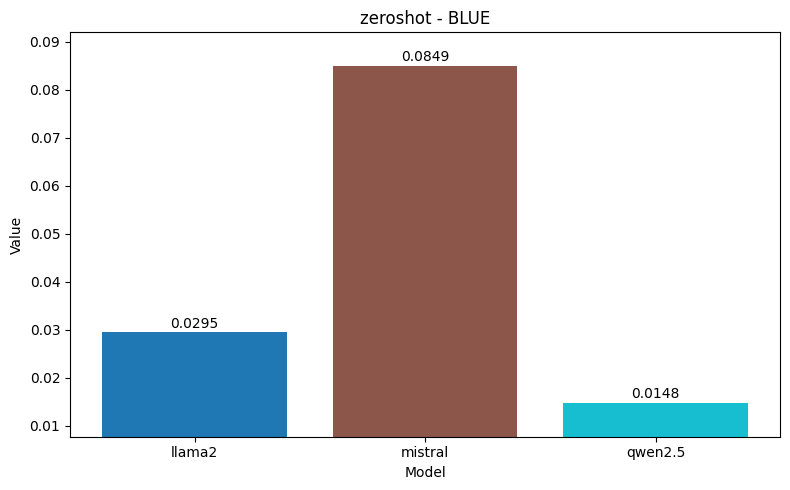

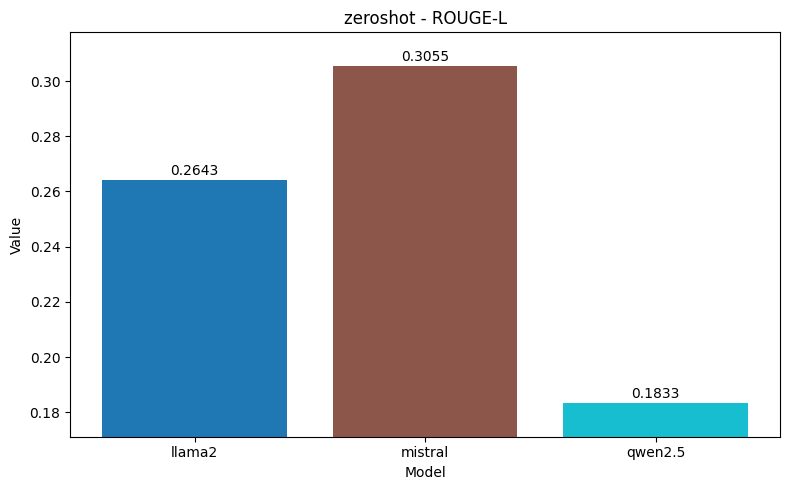

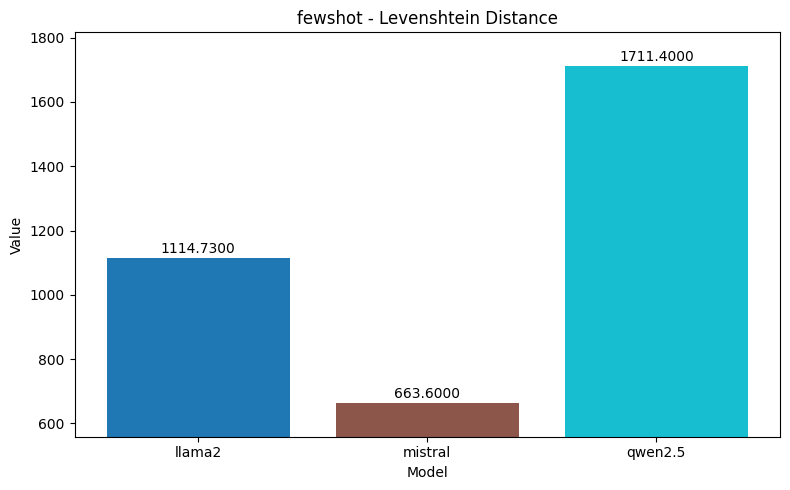

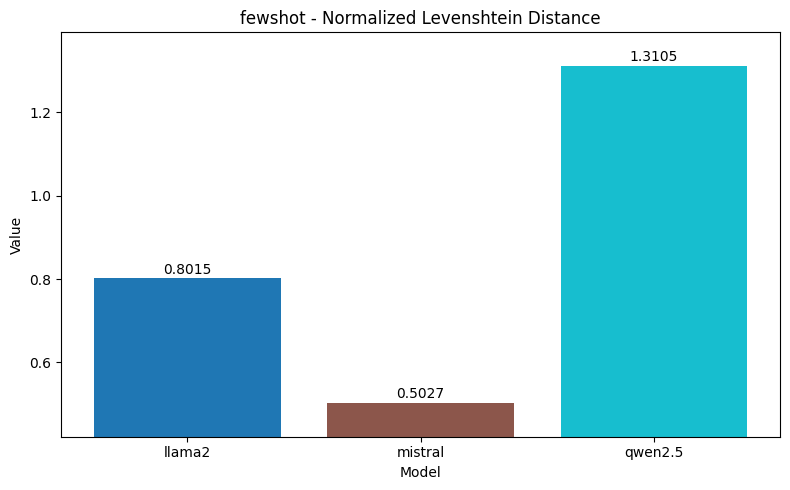

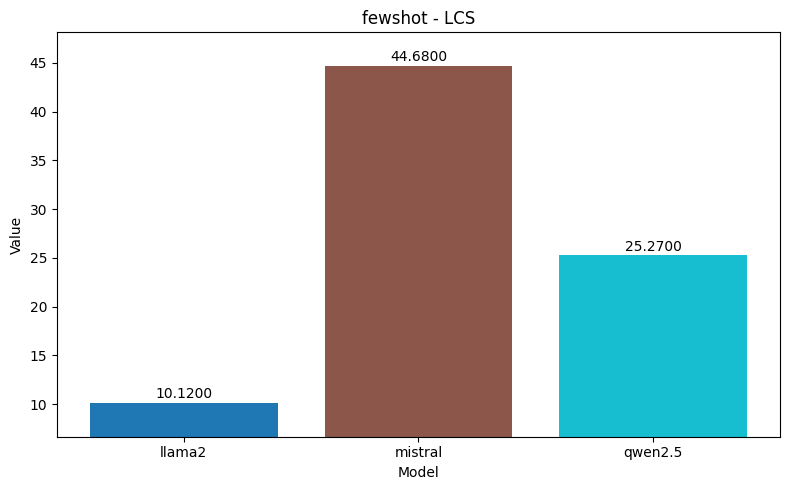

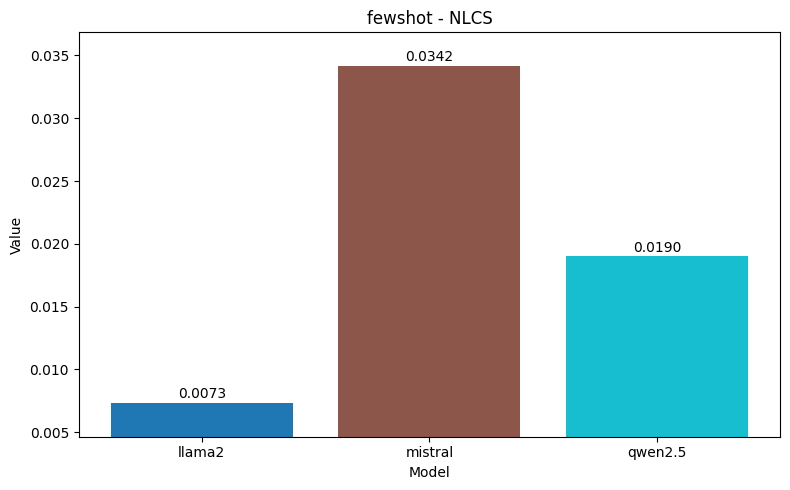

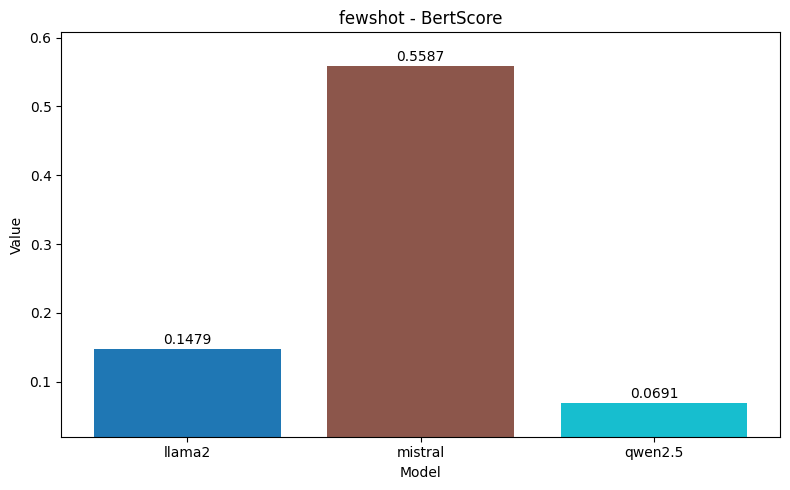

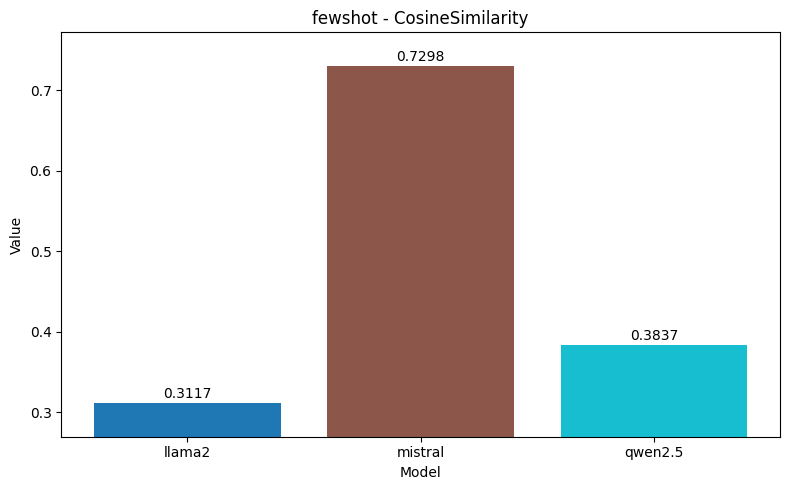

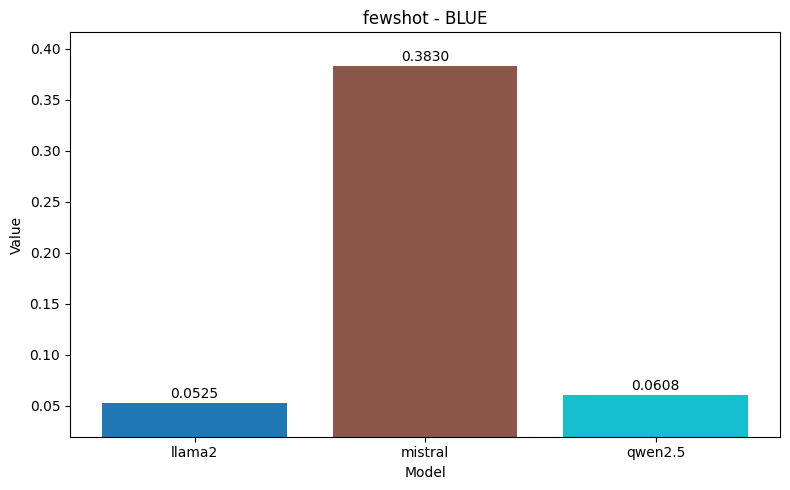

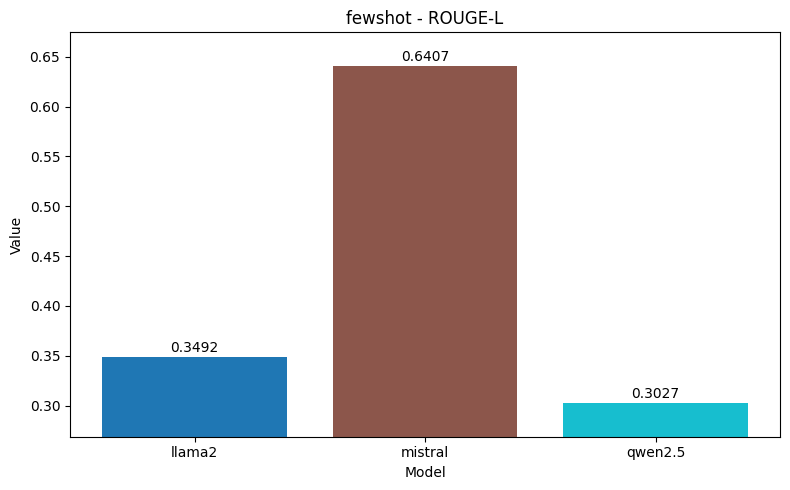

In [84]:
final_df = pd.concat(final_rows, ignore_index=True)

final_df['Model'] = final_df['Model'].astype(str)

model_order = ['llama2', 'mistral', 'qwen2.5']
base_colors = matplotlib.colormaps['tab10'](np.linspace(0, 1, len(model_order)))
color_map = dict(zip(model_order, base_colors))

metric1 = ['Levenshtein Distance', 'Normalized Levenshtein Distance', 'LCS', 'NLCS',
           'BertScore', 'CosineSimilarity', 'BLUE', 'ROUGE-L']
prompting_list = final_df['Prompting'].unique()

for prompt in prompting_list:
    for metrik in metric1:
        plot_bar_one_metric_prompting(final_df, metrik, prompt, model_order, color_map)


## Run Role-Playing Experiment

In [ ]:
#OPEN DATASET
with open("data/weather/roleplaying_mistral_100fewzeroshot.json", "r",encoding='utf-8') as f:
    content = json.load(f)

In [ ]:
demo = WeatherDemo(
        content=content,
        candidates=["fewshot-weather man-mistral","zeroshot-weather man-mistral"],
        judges=["zeroshot-weather_journalist-gpt-4-turbo","zeroshot-meteorologist-gpt-4-turbo"],
        exp="weather_mistral_eval",
        concurrency=5
    )
